# <span style="color:red"> Lecture 22b: Grouping and Aggregating </span>

<font size = "4">

This notebook discusses

- Extracting groups of a dataset
- Computing aggregate statistics by group


# <span style="color:red"> I. Grouping </span>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<font size = "4">
We will use the Formula One datasets, stored in the folder "f1_raw_data". 
<br>

[See Data Source](https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020)
<br>

We'll begin with "results.csv". Using ``.dtypes`` allows us to see all the column headings, along with their data-types


In [3]:
df_results = pd.read_csv("f1_raw_data/results.csv")
print(df_results.dtypes)

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
dtype: object


<font size = "4">

There are 5 "ID" columns, resultId, raceId, driverId, constructorId, statusId.


Let's check how how many rows there are in the dataset, and how many **unique** values of these ID's there are

In [4]:
# There are a variety of ways to find this information...

print("Number of rows:", len(df_results))
print("Unique resultId:", len(pd.unique(df_results["resultId"])))
print("Unique raceId:", len(pd.unique(df_results["raceId"])))
print("Unique driverId:", len(pd.unique(df_results["driverId"])))
print("Unique constructorId:", len(df_results["constructorId"].unique()))
print("Unique statusId:", df_results["statusId"].nunique())


Number of rows: 25660
Unique resultId: 25660
Unique raceId: 1070
Unique driverId: 854
Unique constructorId: 210
Unique statusId: 137


<font size = "4">

Based on a driver's finish, a certain number of points is assigned, which corresponds to the "points" column.


We could, for example, compute the mean of this column to compute the average number of points per result. This doesn't seem like a very interesting statistic however.

But, if we could compute the average points for each driver, or each constructor (the entity which built the car). This would give us important information: which drivers/cars perform the best.

We can do this in Pandas using the ``.groupby`` method

In [5]:
driver_group = df_results.groupby(by = "driverId")
constructor_group = df_results.groupby(by = "constructorId")

# First question to always ask with a new function:
# what kind of thing does it output?
print(type(driver_group))

# 2nd: what does it look like?
print(driver_group)

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>


<font size = "4">

This returns a "DataFrameGroupBy" object, and printing it gives no information (just like for ``range`` and ``zip``).

When you do ``range(10)`` it does **not** create an object with the numbers 0, 1, 2, ..., 8, 9. It creates a range object that "knows" how to generate the integers from 0 to 9 one-by-one. It doesn't generate these numbers until they are needed, such as a for loop.

When you do ``zip(list_1, list_2)`` it does **not** create an object containing all the pairs between the lists. It creates a zip object that "knows" how to generate the pairs one-by-one. It doesn't generate these pairs until they are needed, such as a for loop. 



In [6]:
list_1 = [5.3, "Pandas", -9]
list_2 = ["Number", 0, 12]

zip_lists = zip(list_1, list_2)


print(type(zip_lists))
print(zip_lists)

# The variable zip_lists is "associated" or "linked" 
# with the original lists. It draws the elements from 
# those lists when needed.

<class 'zip'>


<font size = "4">

Similarly, a DataFrameGroupBy object is "associated" or "linked" with the original DataFrame object. To get something useful, we need to specify:

- Column/variable
- An operation

In [7]:
# Choose "points" and compute its average
driver_mean_points = driver_group["points"].mean()
display(driver_mean_points)
print()
print(type(driver_mean_points))

driverId
1      14.313953
2       1.407609
3       7.740291
4       5.790831
5       0.937500
         ...    
851     0.000000
852     1.228571
853     0.000000
854     0.342857
855     0.384615
Name: points, Length: 854, dtype: float64


<class 'pandas.core.series.Series'>


<font size = "4">

We can see that "Driver 1" scores an average of 14.31 points per race. Driver 2 only scores an average of 1.41 points per race.

Let's grab the 5 top performing drivers

In [8]:
mean_pts_sorted = driver_mean_points.sort_values(ascending = False)

# This is a *Series*. Only needs one integer (or range of integers).
# A DataFrame needs two integers (row and column)
display(mean_pts_sorted.iloc[:5]) 

driverId
1      14.313953
830    11.639610
20     10.573883
822     9.244792
3       7.740291
Name: points, dtype: float64

<font size = "4">

To go from driverId to the driver's name, you would need to use "drivers.csv". The best performing driver (with driverId 1) is Lewis Hamilton
<br>

Could also compute the mean of both "points" and "positionOrder" (since they are both numerical)

In [9]:
mean_pts_position = driver_group[["points", "positionOrder"]].mean()
display(mean_pts_position)

,points,positionOrder
driverId,,
1,14.313953,4.707641
2,1.407609,10.722826
3,7.740291,8.252427
4,5.790831,8.409742
5,0.937500,13.285714
...,...,...
851,0.000000,16.000000
852,1.228571,13.657143
853,0.000000,17.863636


<font size = "4">

Can "chain" together all the commands instead of breaking them up into single lines

In [10]:
#### Starting with the DataFrame, we did the following steps to get
#### the top 5 performers:

# driver_group = df_results.groupby(by = "driverId")
# driver_mean_points = driver_group["points"].mean()
# mean_pts_sorted = driver_mean_points.sort_values(ascending = False)
# print(mean_pts_sorted.iloc[:5])


top5_one_line = df_results.groupby(by = "driverId")["points"].mean().sort_values(ascending=False).iloc[:5]
display(top5_one_line)

driverId
1      14.313953
830    11.639610
20     10.573883
822     9.244792
3       7.740291
Name: points, dtype: float64

In [11]:
# It's considered good practice to make each line less than 80 characters
# This makes it easier to scroll up and down without going sideways.
# Can use the backslash (\) for a new line

top5_one_line = df_results.groupby(by = "driverId")["points"].mean().\
    sort_values(ascending=False).iloc[:5]
display(top5_one_line)

driverId
1      14.313953
830    11.639610
20     10.573883
822     9.244792
3       7.740291
Name: points, dtype: float64

In [12]:
# Can also add parentheses around everything on the right
# Then can use multiple lines

top5_one_line = (df_results.groupby(by = "driverId")["points"].mean().
    sort_values(ascending=False).iloc[:5])
print(top5_one_line)

driverId
1      14.313953
830    11.639610
20     10.573883
822     9.244792
3       7.740291
Name: points, dtype: float64


# <span style="color:red"> II. Aggregating Statistics </span>

<font size = "4">

Suppose we want to compute the mean, standard deviation, minimum, and maximum of "points" for the entire dataset

Most straightforward way is:

In [13]:
pts_col = df_results["points"]
pts_mean = pts_col.mean()
pts_std = pts_col.std()
pts_min = pts_col.min()
pts_max = pts_col.max()

<font size = "4">

Can compute these in one command using ``.agg`` (which stands for aggregate)

In [15]:
pts_col = df_results["points"]

pts_stats = pts_col.agg(["mean", "std", "min", "max"])

print(pts_stats)
print()
print(type(pts_stats))
display(pts_stats)

mean     1.854523
std      4.131527
min      0.000000
max     50.000000
Name: points, dtype: float64

<class 'pandas.core.series.Series'>


mean     1.854523
std      4.131527
min      0.000000
max     50.000000
Name: points, dtype: float64

<font size = "4">

The ``.agg`` function is very flexible. By rule, the more flexible a function is, the harder it is to learn. 

Both Pandas Series and DataFrames have a method called `.agg`. If you type ``help(df_results.agg)``, you will see the documentation, along with some very simple examples.

Note that the examples for ``help(pts_col.agg)`` will be different, because it is a **Series**, while "df_results" is a **DataFrame**

In [16]:
help(df_results.agg)

Help on method aggregate in module pandas.core.frame:

aggregate(func=None, axis: 'Axis' = 0, *args, **kwargs) method of pandas.core.frame.DataFrame instance
    Aggregate using one or more operations over the specified axis.

    Parameters
    ----------
    func : function, str, list or dict
        Function to use for aggregating the data. If a function, must either
        work when passed a DataFrame or when passed to DataFrame.apply.

        Accepted combinations are:

        - function
        - string function name
        - list of functions and/or function names, e.g. ``[np.sum, 'mean']``
        - dict of axis labels -> functions, function names or list of such.
    axis : {0 or 'index', 1 or 'columns'}, default 0
            If 0 or 'index': apply function to each column.
            If 1 or 'columns': apply function to each row.
    *args
        Positional arguments to pass to `func`.
    **kwargs
        Keyword arguments to pass to `func`.

    Returns
    -------
  

<font size = "4">

Let's look at the examples for a DataFrame:

In [14]:
df_example = pd.DataFrame([[1, 2, 3],
                           [4, 5, 6],
                           [7, 8, 9], 
                           [np.nan, np.nan, np.nan]], 
                           columns=['A', 'B', 'C'])
display(df_example)

,A,B,C
0,1.0,2.0,3.0
1,4.0,5.0,6.0
2,7.0,8.0,9.0
3,NaN,NaN,NaN


In [15]:
# Aggregate the sum and minimum functions over the rows
example_1 = df_example.agg(["sum", "min"])
display(example_1)

,A,B,C
sum,12.0,15.0,18.0
min,1.0,2.0,3.0


In [17]:
# Different aggregations per column
example_2 = df_example.agg({'A' : ['sum', 'min'], 'B' : ['min', 'max']})
display(example_2)

,A,B
sum,12.0,NaN
min,1.0,2.0
max,NaN,8.0


In [19]:
# Aggregate different functions over the columns 
# and rename the index of the resulting DataFrame.
example_3 = df_example.agg(A_max = ('A', 'max'),
                           B_min = ('B', 'min'),
                           C_mean = ('C', 'mean'))
                           

display(example_3)

,A,B,C
A_max,7.0,NaN,NaN
B_min,NaN,2.0,NaN
C_mean,NaN,NaN,6.0


In [20]:
# Aggregate over the columns
example_4 = df_example.agg("mean", axis="columns")
display(example_4)

0    2.0
1    5.0
2    8.0
3    NaN
dtype: float64

<font size = "4">

With these examples in mind, we can return to our original DataFrame

In [22]:
results_agg = df_results.agg(mean_points = ('points','mean'),
                          sd_points =   ('points','std'),
                          min_points =  ('points','min'),
                          max_points =  ('points','max'))

display(results_agg)

,points
mean_points,1.854523
sd_points,4.131527
min_points,0.000000
max_points,50.000000


In [23]:
def count_unique(col):
    return len(col.unique())

results_agg = df_results.agg(mean_points = ('points','mean'),
                          mean_laps =   ('laps','mean'),
                          min_points =  ('points','min'),
                          max_points =  ('points','max'),
                          num_drivers = ('driverId', count_unique))

display(results_agg)

,points,laps,driverId
mean_points,1.854523,NaN,NaN
mean_laps,NaN,45.936204,NaN
min_points,0.000000,NaN,NaN
max_points,50.000000,NaN,NaN
num_drivers,NaN,NaN,854.0


# <span style="color:red"> III. Grouping + Aggregating </span>


<img src="figures/agg.png" alt="drawing" width="400"/>

In [24]:
drivers_agg = (df_results.groupby("driverId")
                      .agg(mean_points = ('points','mean'),
                           sd_points =   ('points','std'),
                           min_points =  ('points','min'),
                           max_points =  ('points','max'),
                           appearances   = ('points',len)))

print(type(drivers_agg))
display(drivers_agg)

<class 'pandas.core.frame.DataFrame'>


,mean_points,sd_points,min_points,max_points,appearances
driverId,,,,,
1,14.313953,9.246906,0.0,50.0,301
2,1.407609,2.372923,0.0,15.0,184
3,7.740291,8.672456,0.0,25.0,206
4,5.790831,6.372925,0.0,25.0,349
5,0.937500,1.969503,0.0,10.0,112
...,...,...,...,...,...
851,0.000000,NaN,0.0,0.0,1
852,1.228571,2.734160,0.0,12.0,35
853,0.000000,0.000000,0.0,0.0,22


In [25]:
# driverId is the "Index" column, NOT a regular column
print(drivers_agg.columns.values)

['mean_points' 'sd_points' 'min_points' 'max_points' 'appearances']


<font size = "4" >

Groupby + Aggregate statistics (multigroup)

Each constructor can have multiple vehicles competing in a given race. We'll group by Race ID and Constructor ID, then aggregate statistics. This will allow us to see how each constructor did relative to the others in a given race.

In [39]:
teamrace_agg = (df_results.groupby(  ["raceId","constructorId"]    )
                       .agg(mean_points = ('points','mean'),
                            sd_points =   ('points','std'),
                            min_points =  ('points','min'),
                            max_points =  ('points','max'),
                            cars_entered   = ('points',len)))

display(teamrace_agg)

mean_points  sd_points  min_points  max_points  \
raceId constructorId                                                   
1      1                      0.0   0.000000         0.0         0.0   
       2                      0.0   0.000000         0.0         0.0   
       3                      1.5   2.121320         0.0         3.0   
       4                      2.0   2.828427         0.0         4.0   
       5                      1.5   0.707107         1.0         2.0   
...                           ...        ...         ...         ...   
1086   117                    0.5   0.707107         0.0         1.0   
       131                   17.0   2.828427        15.0        19.0   
       210                    0.0   0.000000         0.0         0.0   
       213                    0.0   0.000000         0.0         0.0   
       214                    3.0   1.414214         2.0         4.0   

                      cars_entered  
raceId constructorId                
1      1                         2  
       2                         2  
       3                         2  
       4                         2  
       5                         2  
...                            ...  
1086   117                       2  
       131                       2  
       210                       2  
       213                       2  
       214                       2  

[12478 rows x 5 columns]

<font size = "4">

This is one situation where print is actually better than display:

In [27]:
print(teamrace_agg)

                      mean_points  sd_points  min_points  max_points  \
raceId constructorId                                                   
1      1                      0.0   0.000000         0.0         0.0   
       2                      0.0   0.000000         0.0         0.0   
       3                      1.5   2.121320         0.0         3.0   
       4                      2.0   2.828427         0.0         4.0   
       5                      1.5   0.707107         1.0         2.0   
...                           ...        ...         ...         ...   
1086   117                    0.5   0.707107         0.0         1.0   
       131                   17.0   2.828427        15.0        19.0   
       210                    0.0   0.000000         0.0         0.0   
       213                    0.0   0.000000         0.0         0.0   
       214                    3.0   1.414214         2.0         4.0   

                      cars_entered  
raceId constructorId      

<font size = "4">

Filtering + Grouping + Aggregating: <br>

```python 
.query().groupby().agg()
```

- Another example of "chaining"

In [28]:
# The following gets a subset of the data using .query()
# In this case we subset the data before computing aggregate statistics
# Note: "filtering" is often the word used to obtain a subset

teamrace_agg = (df_results.query("raceId >= 500")
                       .groupby(["raceId","constructorId"])
                        .agg(mean_points = ('points','mean'),
                             sd_points =   ('points','std'),
                             min_points =  ('points','min'),
                             max_points =  ('points','max'),
                             cars_entered   = ('points',len)))
print(teamrace_agg)

                      mean_points  sd_points  min_points  max_points  \
raceId constructorId                                                   
500    1                      0.0   0.000000         0.0         0.0   
       3                      1.0   1.414214         0.0         2.0   
       4                      4.5   6.363961         0.0         9.0   
       6                      0.0   0.000000         0.0         0.0   
       21                     0.5   0.707107         0.0         1.0   
...                           ...        ...         ...         ...   
1086   117                    0.5   0.707107         0.0         1.0   
       131                   17.0   2.828427        15.0        19.0   
       210                    0.0   0.000000         0.0         0.0   
       213                    0.0   0.000000         0.0         0.0   
       214                    3.0   1.414214         2.0         4.0   

                      cars_entered  
raceId constructorId      

In [29]:
# maybe we're only interested in the mean
teamrace_mean = (df_results.query("raceId >= 500").groupby(["raceId","constructorId"]).
    agg(mean_points = ('points','mean')))

print(teamrace_mean)

                      mean_points
raceId constructorId             
500    1                      0.0
       3                      1.0
       4                      4.5
       6                      0.0
       21                     0.5
...                           ...
1086   117                    0.5
       131                   17.0
       210                    0.0
       213                    0.0
       214                    3.0

[5965 rows x 1 columns]


<font size = "4">

**Exercise:** Perform the following by chaining. Create a DataFrame where for each race (identified by "raceId") we aggregate the average number of laps and the average number of points.

In [ ]:
# your code here


<font size = "4">

**Exercise:** Perform the following by chaining. For each constructor (identified by "constructorId"), aggregate the average number of points, then sort in descending order.

In [ ]:
# your code here



# <span style="color:red"> IV. Aggregating + Merging  </span>


<img src="figures/merge_stats.png" alt="drawing" width="600"/>

<font size = "4">

We have the original DataFrame ("df_results"), and we have aggregate statistics for each driver ("drivers_agg"). We'll merge these two together

In [30]:
df_results

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25655,25661,1086,825,210,20,13,16,16,16,0.0,69,\N,\N,37,15,1:23.511,188.856,11
25656,25662,1086,848,3,23,17,17,17,17,0.0,69,\N,\N,43,12,1:23.047,189.911,11
25657,25663,1086,849,3,6,19,18,18,18,0.0,69,\N,\N,60,8,1:22.478,191.221,11
25658,25664,1086,852,213,22,16,19,19,19,0.0,68,\N,\N,58,16,1:23.538,188.795,12


In [31]:
drivers_agg

,mean_points,sd_points,min_points,max_points,appearances
driverId,,,,,
1,14.313953,9.246906,0.0,50.0,301
2,1.407609,2.372923,0.0,15.0,184
3,7.740291,8.672456,0.0,25.0,206
4,5.790831,6.372925,0.0,25.0,349
5,0.937500,1.969503,0.0,10.0,112
...,...,...,...,...,...
851,0.000000,NaN,0.0,0.0,1
852,1.228571,2.734160,0.0,12.0,35
853,0.000000,0.000000,0.0,0.0,22


In [32]:
results_merge = pd.merge(df_results,
                         drivers_agg,
                         on = "driverId",
                         how = "left")

In [33]:
display(results_merge)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,mean_points,sd_points,min_points,max_points,appearances
0,1,18,1,1,22,1,1,1,1,10.0,...,39,2,1:27.452,218.300,1,14.313953,9.246906,0.0,50.0,301
1,2,18,2,2,3,5,2,2,2,8.0,...,41,3,1:27.739,217.586,1,1.407609,2.372923,0.0,15.0,184
2,3,18,3,3,7,7,3,3,3,6.0,...,41,5,1:28.090,216.719,1,7.740291,8.672456,0.0,25.0,206
3,4,18,4,4,5,11,4,4,4,5.0,...,58,7,1:28.603,215.464,1,5.790831,6.372925,0.0,25.0,349
4,5,18,5,1,23,3,5,5,5,4.0,...,43,1,1:27.418,218.385,1,0.937500,1.969503,0.0,10.0,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25655,25661,1086,825,210,20,13,16,16,16,0.0,...,37,15,1:23.511,188.856,11,1.330827,2.846374,0.0,18.0,133
25656,25662,1086,848,3,23,17,17,17,17,0.0,...,43,12,1:23.047,189.911,11,3.921569,4.853218,0.0,15.0,51
25657,25663,1086,849,3,6,19,18,18,18,0.0,...,60,8,1:22.478,191.221,11,0.134615,0.840841,0.0,6.0,52
25658,25664,1086,852,213,22,16,19,19,19,0.0,...,58,16,1:23.538,188.795,12,1.228571,2.734160,0.0,12.0,35


<font size = "4">

**Exercise:** Compute a scatter plot of "points" (horizontal axis) vs. "mean_points" (vertical axis). This plot tries to describe how much a driver's performance in individual races deviates from their overall average.

Text(0, 0.5, 'avg points')

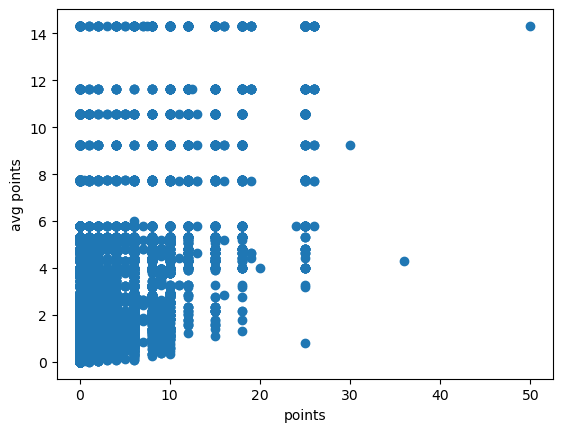

In [35]:
# your code here

plt.scatter(x= results_merge["points"], y= results_merge["mean_points"])
plt.xlabel("points")
plt.ylabel("avg points")


<font size = "4">

**Exercise:** Merge the "teamrace_agg" data into "df_results". This time use the option:

```python
        on = ["raceId","constructorId"]
```

In [41]:
# your code here

merged = pd.merge(left= df_results, right= teamrace_agg, how= "driverID", on= ["raceID", "constructorID"])
display(merged)


KeyError: 'raceID'